In [2]:
import os
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize

warnings.filterwarnings("ignore")

2026-06-11 05:13:07.288927: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781154787.482017      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781154787.534255      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781154787.985611      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781154787.985658      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781154787.985660      58 computation_placer.cc:177] computation placer alr

In [3]:
import os

print("Folders inside /kaggle/input:")
print(os.listdir("/kaggle/input"))

print("\nComplete folder structure:\n")

for root, dirs, files in os.walk("/kaggle/input"):
    print(root)

Folders inside /kaggle/input:
['datasets']

Complete folder structure:

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/masoudnickparvar
/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset
/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training
/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training/pituitary
/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training/notumor
/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training/meningioma
/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training/glioma
/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Testing
/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Testing/pituitary
/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Testing/notumor
/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Testing/meningioma
/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Testi

In [4]:
import os

base_dir = None

print("Searching for dataset...\n")

for root, dirs, files in os.walk("/kaggle/input"):
    if "Training" in dirs and "Testing" in dirs:
        base_dir = root
        break

if base_dir is None:
    raise FileNotFoundError(
        "Training and Testing folders not found. Please make sure you have added the Brain Tumor MRI Dataset to your Kaggle notebook."
    )

train_dir = os.path.join(base_dir, "Training")
test_dir = os.path.join(base_dir, "Testing")

print("Dataset Found!")
print("Base Directory :", base_dir)
print("Training Directory :", train_dir)
print("Testing Directory :", test_dir)

print("\nClasses Available:")
classes = sorted(os.listdir(train_dir))
for i, cls in enumerate(classes, start=1):
    print(f"{i}. {cls}")

Searching for dataset...

Dataset Found!
Base Directory : /kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset
Training Directory : /kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training
Testing Directory : /kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Testing

Classes Available:
1. glioma
2. meningioma
3. notumor
4. pituitary


In [5]:
classes = sorted(os.listdir(train_dir))

print("Classes Found:\n")

for i, cls in enumerate(classes, start=1):
    print(f"{i}. {cls}")

Classes Found:

1. glioma
2. meningioma
3. notumor
4. pituitary


In [6]:
train_count = {}
test_count = {}

for cls in classes:
    train_count[cls] = len(os.listdir(os.path.join(train_dir, cls)))
    test_count[cls] = len(os.listdir(os.path.join(test_dir, cls)))

print("Training Images:\n")
for cls, count in train_count.items():
    print(f"{cls}: {count}")

print("\nTesting Images:\n")
for cls, count in test_count.items():
    print(f"{cls}: {count}")

Training Images:

glioma: 1400
meningioma: 1400
notumor: 1400
pituitary: 1400

Testing Images:

glioma: 400
meningioma: 400
notumor: 400
pituitary: 400


In [7]:
summary_df = pd.DataFrame({
    "Class": classes,
    "Training Images": [train_count[c] for c in classes],
    "Testing Images": [test_count[c] for c in classes]
})

summary_df["Total Images"] = (
    summary_df["Training Images"] +
    summary_df["Testing Images"]
)

summary_df.index = np.arange(1, len(summary_df) + 1)

summary_df

,Class,Training Images,Testing Images,Total Images
1,glioma,1400,400,1800
2,meningioma,1400,400,1800
3,notumor,1400,400,1800
4,pituitary,1400,400,1800


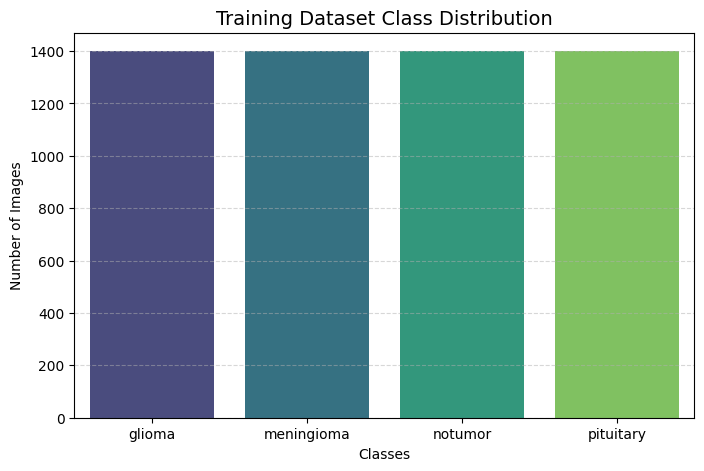

In [8]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=summary_df["Class"],
    y=summary_df["Training Images"],
    palette="viridis"
)

plt.title("Training Dataset Class Distribution", fontsize=14)
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

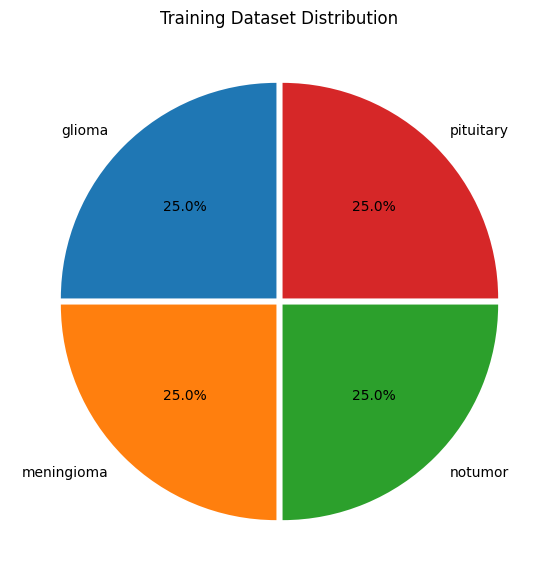

In [9]:
plt.figure(figsize=(7,7))

plt.pie(
    summary_df["Training Images"],
    labels=summary_df["Class"],
    autopct="%1.1f%%",
    startangle=90,
    explode=[0.02, 0.02, 0.02, 0.02]
)

plt.title("Training Dataset Distribution")

plt.show()

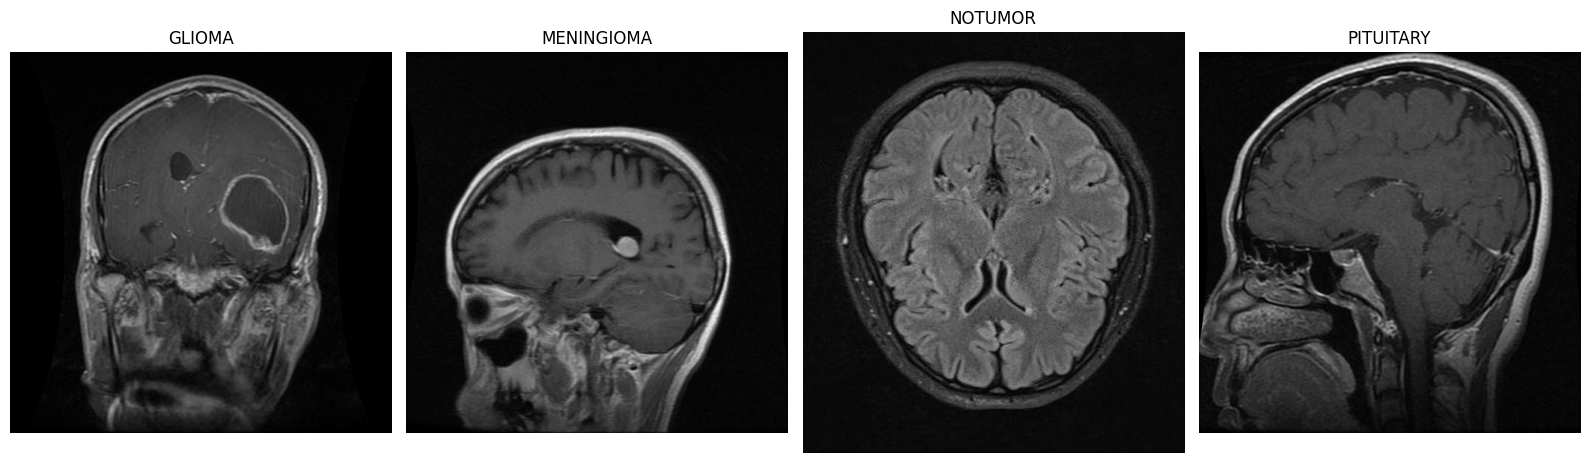

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(16,5))

for i, cls in enumerate(classes):
    folder = os.path.join(train_dir, cls)
    img_name = random.choice(os.listdir(folder))
    img_path = os.path.join(folder, img_name)

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    axes[i].imshow(img)
    axes[i].set_title(cls.upper())
    axes[i].axis("off")

plt.tight_layout()
plt.show()

Average Height : 456.98
Average Width  : 454.1


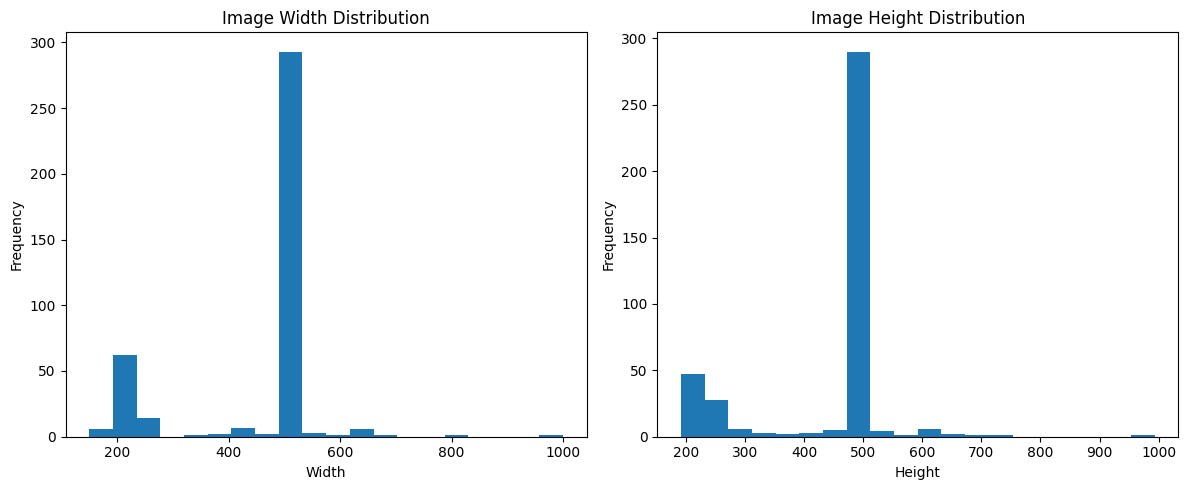

In [11]:
widths = []
heights = []

for cls in classes:
    folder = os.path.join(train_dir, cls)

    for img_name in os.listdir(folder)[:100]:
        img = cv2.imread(os.path.join(folder, img_name))

        if img is not None:
            h, w, _ = img.shape
            heights.append(h)
            widths.append(w)

print("Average Height :", round(np.mean(heights), 2))
print("Average Width  :", round(np.mean(widths), 2))

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(widths, bins=20)
plt.title("Image Width Distribution")
plt.xlabel("Width")
plt.ylabel("Frequency")

plt.subplot(1,2,2)
plt.hist(heights, bins=20)
plt.title("Image Height Distribution")
plt.xlabel("Height")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

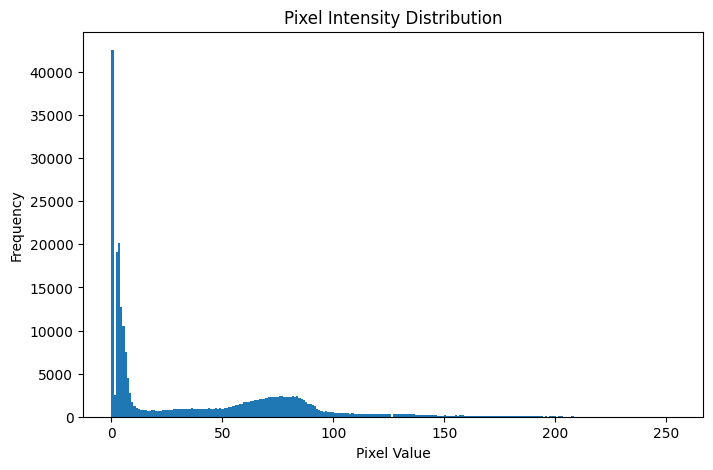

In [12]:
sample_class = random.choice(classes)

sample_folder = os.path.join(train_dir, sample_class)
sample_image = random.choice(os.listdir(sample_folder))

img = cv2.imread(
    os.path.join(sample_folder, sample_image),
    cv2.IMREAD_GRAYSCALE
)

plt.figure(figsize=(8,5))

plt.hist(
    img.ravel(),
    bins=256
)

plt.title("Pixel Intensity Distribution")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")

plt.show()

In [13]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    horizontal_flip=True,
    fill_mode="nearest",
    validation_split=0.2
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [14]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    shuffle=True
)

val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=True
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

print(train_generator.class_indices)

Found 4480 images belonging to 4 classes.
Found 1120 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.
{'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


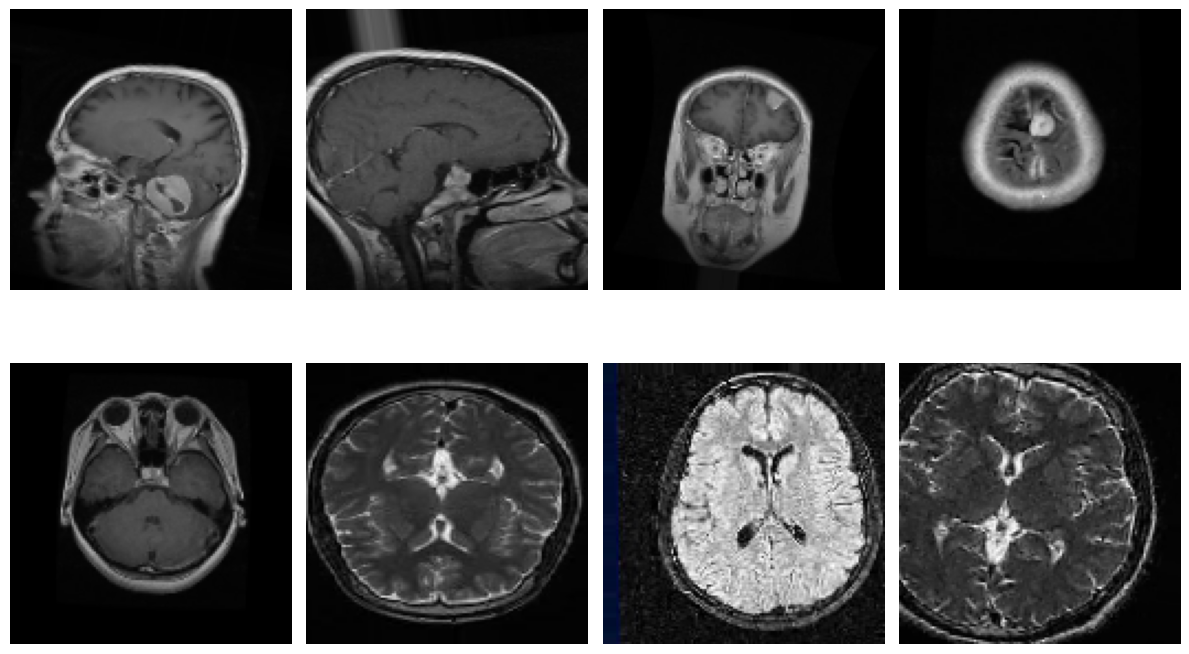

In [15]:
images, labels = next(train_generator)

plt.figure(figsize=(12,8))

for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(images[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [16]:
model = Sequential()

model.add(Conv2D(32, (3,3), activation="relu", input_shape=(128,128,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64, (3,3), activation="relu"))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(128, (3,3), activation="relu"))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(256, (3,3), activation="relu"))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))

model.add(Flatten())

model.add(Dense(512, activation="relu"))
model.add(Dropout(0.5))

model.add(Dense(256, activation="relu"))
model.add(Dropout(0.4))

model.add(Dense(128, activation="relu"))
model.add(Dropout(0.3))

model.add(Dense(4, activation="softmax"))

model.summary()

I0000 00:00:1781154811.525255      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1781154811.531308      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     4,719,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,274,180 (20.12 MB)

 Trainable params: 5,273,220 (20.12 MB)

 Non-trainable params: 960 (3.75 KB)

In [17]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [18]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=6,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "best_brain_tumor_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

callbacks = [
    early_stop,
    checkpoint,
    reduce_lr
]

In [19]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=30,
    callbacks=callbacks
)

Epoch 1/30


I0000 00:00:1781154817.584129     157 service.cc:152] XLA service 0x7a6514002b10 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781154817.584193     157 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1781154817.584201     157 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1781154818.379999     157 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-06-11 05:13:40.505924: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-11 05:13:40.653460: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


  1/140 ━━━━━━━━━━━━━━━━━━━━ 27:10 12s/step - accuracy: 0.2500 - loss: 3.0042

I0000 00:00:1781154825.318810     157 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 325ms/step - accuracy: 0.4415 - loss: 1.6901
Epoch 1: val_accuracy improved from None to 0.25714, saving model to best_brain_tumor_model.keras

Epoch 1: finished saving model to best_brain_tumor_model.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 70s 419ms/step - accuracy: 0.5016 - loss: 1.3636 - val_accuracy: 0.2571 - val_loss: 2.1296 - learning_rate: 1.0000e-04
Epoch 2/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step - accuracy: 0.5641 - loss: 1.0407
Epoch 2: val_accuracy improved from 0.25714 to 0.41429, saving model to best_brain_tumor_model.keras

Epoch 2: finished saving model to best_brain_tumor_model.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 34s 245ms/step - accuracy: 0.5842 - loss: 1.0153 - val_accuracy: 0.4143 - val_loss: 1.8249 - learning_rate: 1.0000e-04
Epoch 3/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step - accuracy: 0.6221 - loss: 0.9320
Epoch 3: val_accuracy improved from 0.41429 to 0.53929, saving model to best_brain_tumor_model.keras

Epoch 3: finished savi

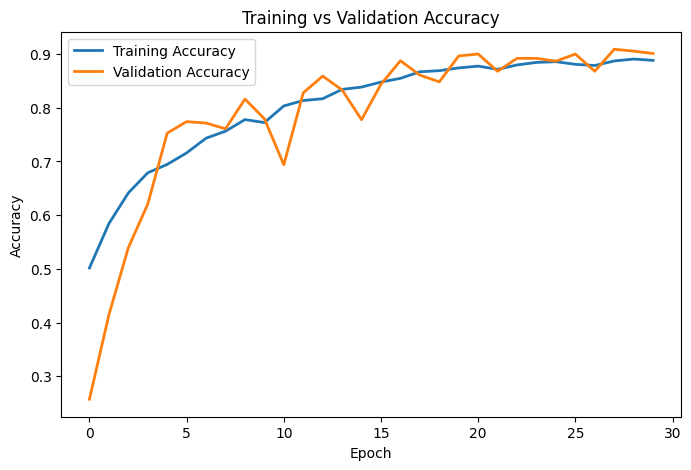

In [20]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy",
    linewidth=2
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy",
    linewidth=2
)

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

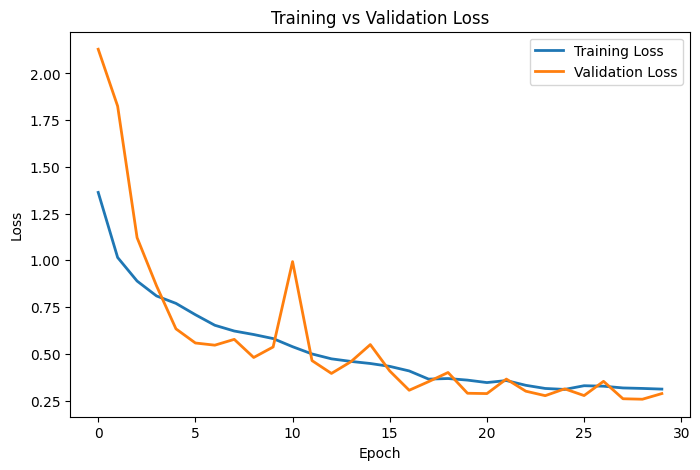

In [21]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history["loss"],
    label="Training Loss",
    linewidth=2
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss",
    linewidth=2
)

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [22]:
test_loss, test_accuracy = model.evaluate(
    test_generator,
    verbose=1
)

print("Test Loss :", round(test_loss, 4))
print("Test Accuracy :", round(test_accuracy * 100, 2), "%")

50/50 ━━━━━━━━━━━━━━━━━━━━ 11s 217ms/step - accuracy: 0.7594 - loss: 0.8762
Test Loss : 0.8762
Test Accuracy : 75.94 %


In [23]:
predictions = model.predict(
    test_generator,
    verbose=1
)

y_pred = np.argmax(
    predictions,
    axis=1
)

y_true = test_generator.classes

class_names = list(
    test_generator.class_indices.keys()
)

print("Classes :", class_names)

50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 72ms/step
Classes : ['glioma', 'meningioma', 'notumor', 'pituitary']


In [24]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

report_df

              precision    recall  f1-score   support

      glioma       0.94      0.62      0.75       400
  meningioma       0.85      0.42      0.56       400
     notumor       0.68      1.00      0.81       400
   pituitary       0.72      1.00      0.84       400

    accuracy                           0.76      1600
   macro avg       0.80      0.76      0.74      1600
weighted avg       0.80      0.76      0.74      1600



,precision,recall,f1-score,support
glioma,0.942966,0.620000,0.748115,400.000000
meningioma,0.847716,0.417500,0.559464,400.000000
notumor,0.680272,1.000000,0.809717,400.000000
pituitary,0.724638,1.000000,0.840336,400.000000
accuracy,0.759375,0.759375,0.759375,0.759375
macro avg,0.798898,0.759375,0.739408,1600.000000
weighted avg,0.798898,0.759375,0.739408,1600.000000


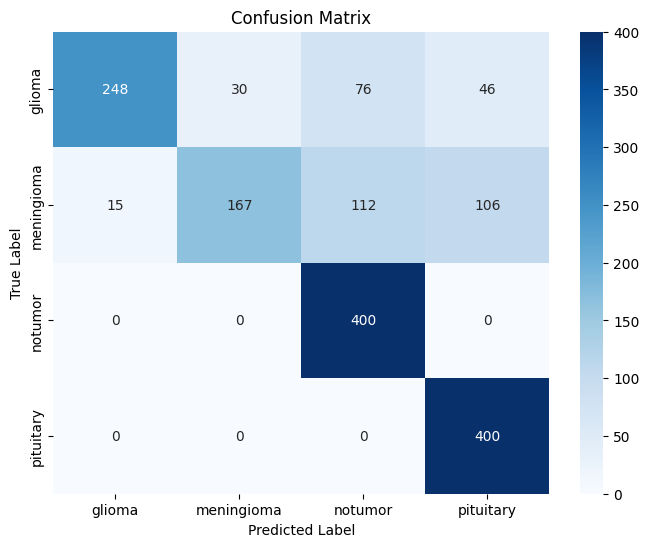

In [25]:
cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()

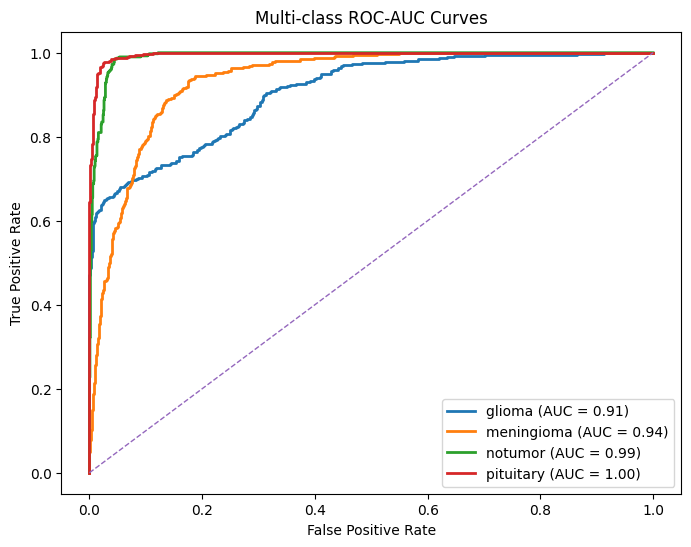

In [26]:
y_true_bin = label_binarize(
    y_true,
    classes=list(range(len(class_names)))
)

plt.figure(figsize=(8,6))

for i in range(len(class_names)):
    fpr, tpr, _ = roc_curve(
        y_true_bin[:, i],
        predictions[:, i]
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{class_names[i]} (AUC = {roc_auc:.2f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-class ROC-AUC Curves")
plt.legend(loc="lower right")

plt.show()

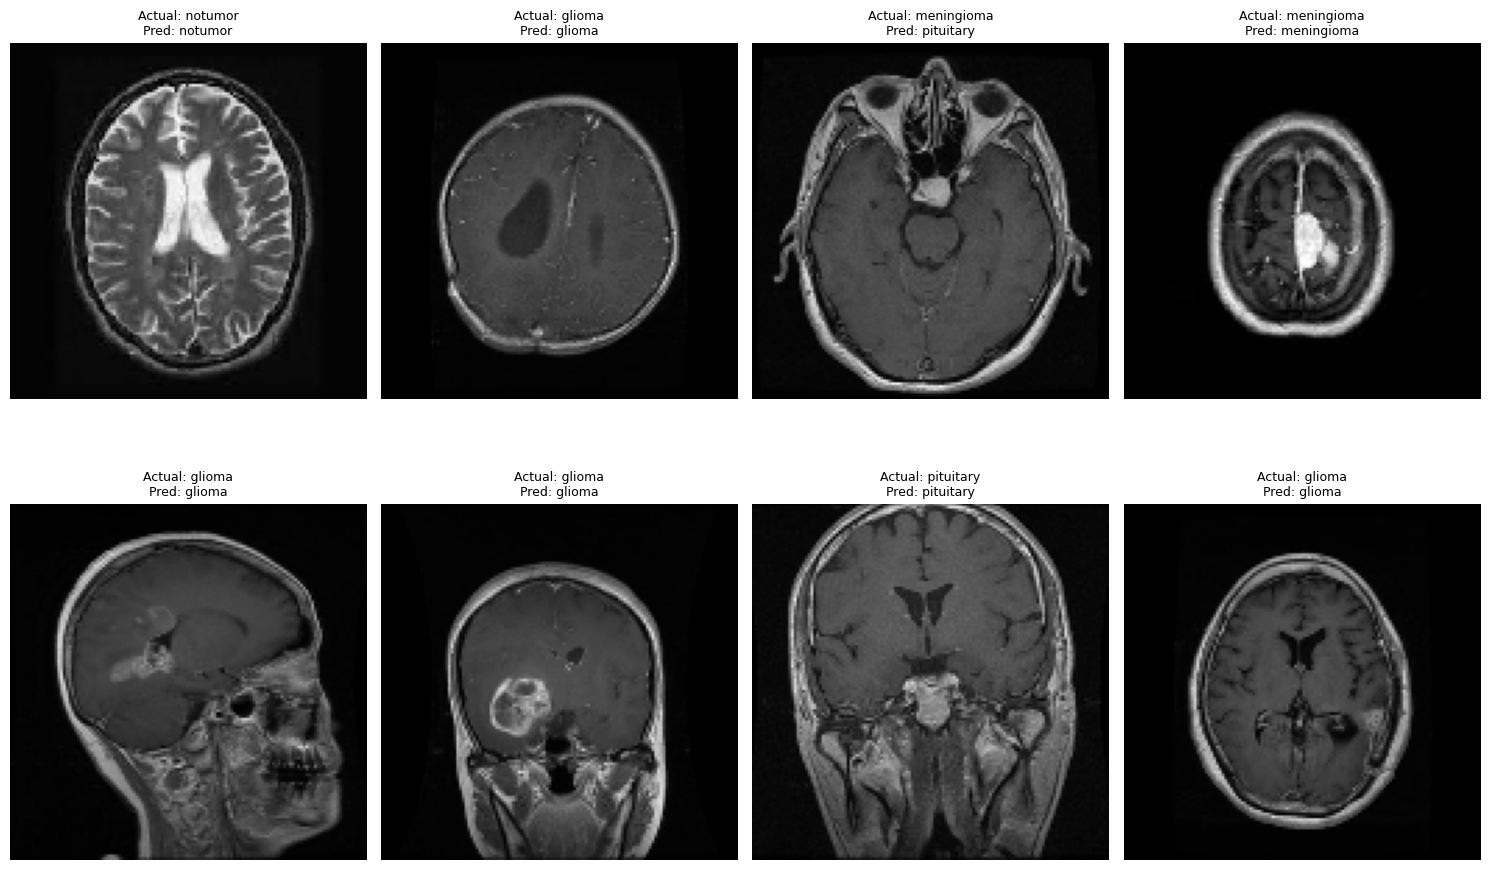

In [27]:
plt.figure(figsize=(15,10))

test_image_paths = []
test_labels = []

for cls in class_names:
    folder = os.path.join(test_dir, cls)

    for img_name in os.listdir(folder):
        test_image_paths.append(
            os.path.join(folder, img_name)
        )
        test_labels.append(cls)

sample_indices = random.sample(
    range(len(test_image_paths)),
    8
)

for i, idx in enumerate(sample_indices):
    img = load_img(
        test_image_paths[idx],
        target_size=(128,128)
    )

    img_array = img_to_array(img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(
        img_array,
        axis=0
    )

    pred = model.predict(
        img_array,
        verbose=0
    )

    pred_label = class_names[
        np.argmax(pred)
    ]

    plt.subplot(2,4,i+1)
    plt.imshow(img)
    plt.title(
        f"Actual: {test_labels[idx]}\nPred: {pred_label}",
        fontsize=9
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

In [28]:
model.save(
    "brain_tumor_custom_cnn.keras"
)

model.save(
    "brain_tumor_custom_cnn.h5"
)

print("Model saved successfully.")

Model saved successfully.


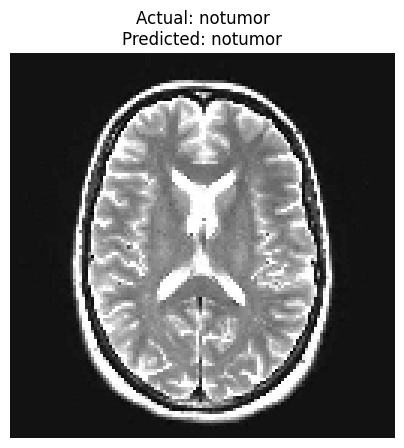

In [29]:
loaded_model = load_model(
    "best_brain_tumor_model.keras"
)

sample_class = random.choice(
    class_names
)

sample_folder = os.path.join(
    test_dir,
    sample_class
)

sample_file = random.choice(
    os.listdir(sample_folder)
)

sample_path = os.path.join(
    sample_folder,
    sample_file
)

img = load_img(
    sample_path,
    target_size=(128,128)
)

img_array = img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(
    img_array,
    axis=0
)

prediction = loaded_model.predict(
    img_array,
    verbose=0
)

predicted_class = class_names[
    np.argmax(prediction)
]

plt.figure(figsize=(5,5))
plt.imshow(img)
plt.title(
    f"Actual: {sample_class}\nPredicted: {predicted_class}"
)
plt.axis("off")
plt.show()